In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:22pt;}
.inner_cell{font-size:22pt;}
div.text_cell_render pre code {font-size:22pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:22pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:22px;}
</style>
"""))

# 딥러닝이란,,데이터의 규칙성을 추출 
- 응용분야:글씨인식,문장분류,값예측,질병진단,얼굴
- ML/DL의 종류
 * 지도학습(입력=독립변수, 타겟=종속변수)
   * 분류분석(타깃변수가 category변수인 분석. 다중분류와 이진분류) vs 회귀분석
 * 비지도학습
   * 군집화(분류분석이전에 입력변수로 가능한지 탐색전용) 
 * 강화학습
   * 지도학습을 강화. ex. 게임에서 승리용으로 다양한 선택 버튼을 눌렀을때 승리할 수 있는 경우의 수를 따져서, 그래서 이 버튼을 누르겠다.(교재부족. 학원에서는 강화학습 안함)
   
- 지도학습에서의 딥러닝 프로그래밍 방식
1. 데이터확보
2. 데이터전처리:결측치처리,스케일조정,인코딩처리(라벨인코딩,원핫인코딩), 분리(학습,검증,시험데이터셋 분리(단결측치있으면 안됨))
3. 모델구성하기(센토사 등 3개)
4. 모델학습과정설정:loss,평가지표..
5. 모델학습시키기(훈련데이터,검증데이터 등으로 분리)
6. 모델평가(모델평가함수 활용. 시험데이터셋으로 평가)..6대2대2(즉, 80%로 학습, 나머지 20%로 평가)
7. 모델저장(로스값이줄어들엇다가 늘어나면 그 갯수에서 바로 저장)
8. 사용(입력값이 주어지면 예측값을 받는다는 의미)..자연어처리는 좀 다르다 

In [3]:
from tensorflow.keras.utils import to_categorical #분류분석시 원핫인코딩(to_categorical추천)
import pandas as pd #원핫인코딩
from tensorflow.keras.models import Sequential, load_model #모델생성,모델load
from tensorflow.keras.layers import Dense, Input #모델에 층을 쌓기 위해서
import numpy as np

## 1. 데이터셋 확보 하기
## 2. 데이터 전처리 하기

In [5]:
#학습데이터=훈련데이터
x_train=np.array([1,2,3,4,5,6,7,8,9]*10)
y_train=np.array([2,3,4,5,6,7,8,9,10]*10)
#검증데이터셋, 시험데이터셋
x_val=np.array([1,2,3,4,5,6,7,8,9])
y_val=np.array([2,3,4,5,6,7,8,9,10])

In [11]:
#인코딩 종류(둘다 해보기 권장)
# 라벨인코딩:문자를 숫자로 변환(서울은 1,경기는 2 등)..sklearn으로 전처리
# 원핫인코딩:값의 갯수만큼 열을 만들고 해당범주에 해당하는 열만 1, 나머지열은 0을 넣음(ex 17개 시도)
#1.라벨인코딩방법
data=np.array(['a','b','c','b','b'])
print('원 데이터:',data)
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# le.fit(data)
# labeling_data=le.transform(data)
labeling_data=le.fit_transform(data)
print('라벨링 코딩된 데이터 : ',labeling_data)

# onehot_encoding_data=to_categorical(data)
onehot_encoding_data=to_categorical(labeling_data)
print('원핫인코딩된 데이터: \n ',onehot_encoding_data)

onehot_encoding_data2=pd.get_dummies(data)
print('원핫인코딩된 데이터2: \n ',onehot_encoding_data2)


원 데이터: ['a' 'b' 'c' 'b' 'b']
라벨링 코딩된 데이터 :  [0 1 2 1 1]
원핫인코딩된 데이터: 
  [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
원핫인코딩된 데이터2: 
     a  b  c
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  1  0


In [15]:
# data=np.array(['a','b','c','b','b'])
data=np.array([1,4,5,4,4])
categorical_onehot=to_categorical(data)
print('to_categorical 이용 \n', categorical_onehot)
#to_categorical를 안쓰는 경우 ==> 곤란하다. 그래서 to_cat.를 써야 한다
getdummies_onehot=pd.get_dummies(data)
print('get_dummies 이용\n',getdummies_onehot)

to_categorical 이용 
 [[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0.]]
get_dummies 이용
    1  4  5
0  1  0  0
1  0  1  0
2  0  0  1
3  0  1  0
4  0  1  0


In [27]:
#분류분석을 위한 종속변(타겟변수)변수의 원핫인코딩
#pd.get_dummies(y_val) ==> 결과가 문제임. 쓰지않음
to_categorical(y_val) #==> 이래야 예측이 좋음
Y_val=to_categorical(y_val)

In [28]:
Y_train=to_categorical(y_train,11)
Y_val=to_categorical(y_val)

In [29]:
#딥러닝모델에 사용될 데이터
x_train.shape,Y_train.shape, x_val.shape,Y_val.shape

((90,), (90, 11), (9,), (9, 11))

In [30]:
Y_val[0]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

# 3. 모델구성

In [32]:
model=Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(units=38,activation='sigmoid')) 
#활성함수:복잡성을피하기위해의미있는데이터만적용하는함수.relu계열.elu..tanh,sigmoid,softmax
model.add(Dense(64,activation='elu'))
model.add(Dense(32,activation='elu'))
model.add(Dense(11,activation='softmax')) #다중분류에서의출력층활성화함수는무조건softmax를 해야 함. 
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 11)                363       
                                                                 
Total params: 5,015
Trainable params: 5,015
Non-trainable params: 0
_________________________________________________________________


# 4. 모델학습과정 설정하기
 - 회귀분석에서의 loss함수는 mse,mae,rmse
 - 다중분류에서의 loss함수는 categorical_crossentropy
 - 이진분류에서의 loss함수는 binary_crossentropy
 - 분류(다중/이진)분석에서의 metrics(평가지표)는 accuracy,recall,precision

In [35]:
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 5. 모델학습시키기

In [36]:
hist=model.fit(x_train, Y_train, #학습데이타셋(입력 및 타겟변수) 
               epochs=300,     #학습횟수
               batch_size=10,
               validation_data=(x_val,Y_val),
               verbose=1)
#verbose=0:학습로그출력없음. 1:기본값, 2:자세한출력


Epoch 1/300
9/9 [==============================] - 1s 55ms/step - loss: 2.4284 - accuracy: 0.1000 - val_loss: 2.3148 - val_accuracy: 0.1111
Epoch 2/300
9/9 [==============================] - 0s 8ms/step - loss: 2.3055 - accuracy: 0.1111 - val_loss: 2.2423 - val_accuracy: 0.1111
Epoch 3/300
9/9 [==============================] - 0s 8ms/step - loss: 2.2193 - accuracy: 0.1889 - val_loss: 2.1662 - val_accuracy: 0.1111
Epoch 4/300
9/9 [==============================] - 0s 7ms/step - loss: 2.1507 - accuracy: 0.1444 - val_loss: 2.1079 - val_accuracy: 0.2222
Epoch 5/300
9/9 [==============================] - 0s 8ms/step - loss: 2.0928 - accuracy: 0.1889 - val_loss: 2.0493 - val_accuracy: 0.3333
Epoch 6/300
9/9 [==============================] - 0s 7ms/step - loss: 2.0305 - accuracy: 0.2556 - val_loss: 1.9918 - val_accuracy: 0.2222
Epoch 7/300
9/9 [==============================] - 0s 8ms/step - loss: 1.9715 - accuracy: 0.2333 - val_loss: 1.9313 - val_accuracy: 0.2222
Epoch 8/300
9/9 [=========

9/9 [==============================] - 0s 7ms/step - loss: 0.4866 - accuracy: 1.0000 - val_loss: 0.4737 - val_accuracy: 1.0000
Epoch 60/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4783 - accuracy: 1.0000 - val_loss: 0.4593 - val_accuracy: 1.0000
Epoch 61/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4618 - accuracy: 1.0000 - val_loss: 0.4481 - val_accuracy: 1.0000
Epoch 62/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4559 - accuracy: 0.9333 - val_loss: 0.4381 - val_accuracy: 1.0000
Epoch 63/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4489 - accuracy: 1.0000 - val_loss: 0.4272 - val_accuracy: 1.0000
Epoch 64/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4254 - accuracy: 1.0000 - val_loss: 0.4128 - val_accuracy: 1.0000
Epoch 65/300
9/9 [==============================] - 0s 7ms/step - loss: 0.4179 - accuracy: 0.9444 - val_loss: 0.4042 - val_accuracy: 0.8889
Epoch 66/300
9/9 [===============

9/9 [==============================] - 0s 7ms/step - loss: 0.0842 - accuracy: 1.0000 - val_loss: 0.0805 - val_accuracy: 1.0000
Epoch 118/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0833 - accuracy: 1.0000 - val_loss: 0.0794 - val_accuracy: 1.0000
Epoch 119/300
9/9 [==============================] - 0s 9ms/step - loss: 0.0794 - accuracy: 1.0000 - val_loss: 0.0758 - val_accuracy: 1.0000
Epoch 120/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0753 - accuracy: 1.0000 - val_loss: 0.0727 - val_accuracy: 1.0000
Epoch 121/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0728 - accuracy: 1.0000 - val_loss: 0.0706 - val_accuracy: 1.0000
Epoch 122/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0713 - accuracy: 1.0000 - val_loss: 0.0685 - val_accuracy: 1.0000
Epoch 123/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0691 - accuracy: 1.0000 - val_loss: 0.0681 - val_accuracy: 1.0000
Epoch 124/300
9/9 [========

9/9 [==============================] - 0s 7ms/step - loss: 0.0193 - accuracy: 1.0000 - val_loss: 0.0188 - val_accuracy: 1.0000
Epoch 176/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0189 - accuracy: 1.0000 - val_loss: 0.0185 - val_accuracy: 1.0000
Epoch 177/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0185 - accuracy: 1.0000 - val_loss: 0.0181 - val_accuracy: 1.0000
Epoch 178/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0180 - accuracy: 1.0000 - val_loss: 0.0177 - val_accuracy: 1.0000
Epoch 179/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0177 - accuracy: 1.0000 - val_loss: 0.0174 - val_accuracy: 1.0000
Epoch 180/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0174 - accuracy: 1.0000 - val_loss: 0.0170 - val_accuracy: 1.0000
Epoch 181/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0170 - accuracy: 1.0000 - val_loss: 0.0167 - val_accuracy: 1.0000
Epoch 182/300
9/9 [========

9/9 [==============================] - 0s 7ms/step - loss: 0.0073 - accuracy: 1.0000 - val_loss: 0.0072 - val_accuracy: 1.0000
Epoch 234/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0072 - accuracy: 1.0000 - val_loss: 0.0071 - val_accuracy: 1.0000
Epoch 235/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0071 - accuracy: 1.0000 - val_loss: 0.0070 - val_accuracy: 1.0000
Epoch 236/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0070 - accuracy: 1.0000 - val_loss: 0.0069 - val_accuracy: 1.0000
Epoch 237/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0069 - accuracy: 1.0000 - val_loss: 0.0068 - val_accuracy: 1.0000
Epoch 238/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0069 - accuracy: 1.0000 - val_loss: 0.0067 - val_accuracy: 1.0000
Epoch 239/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0068 - accuracy: 1.0000 - val_loss: 0.0066 - val_accuracy: 1.0000
Epoch 240/300
9/9 [========

9/9 [==============================] - 0s 9ms/step - loss: 0.0036 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 292/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0036 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 293/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0035 - val_accuracy: 1.0000
Epoch 294/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0035 - accuracy: 1.0000 - val_loss: 0.0034 - val_accuracy: 1.0000
Epoch 295/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.0034 - val_accuracy: 1.0000
Epoch 296/300
9/9 [==============================] - 0s 7ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 297/300
9/9 [==============================] - 0s 8ms/step - loss: 0.0033 - accuracy: 1.0000 - val_loss: 0.0033 - val_accuracy: 1.0000
Epoch 298/300
9/9 [========

# 6. 모델 평가하기(모델 학습과정 살펴보고, evaluate)

In [38]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

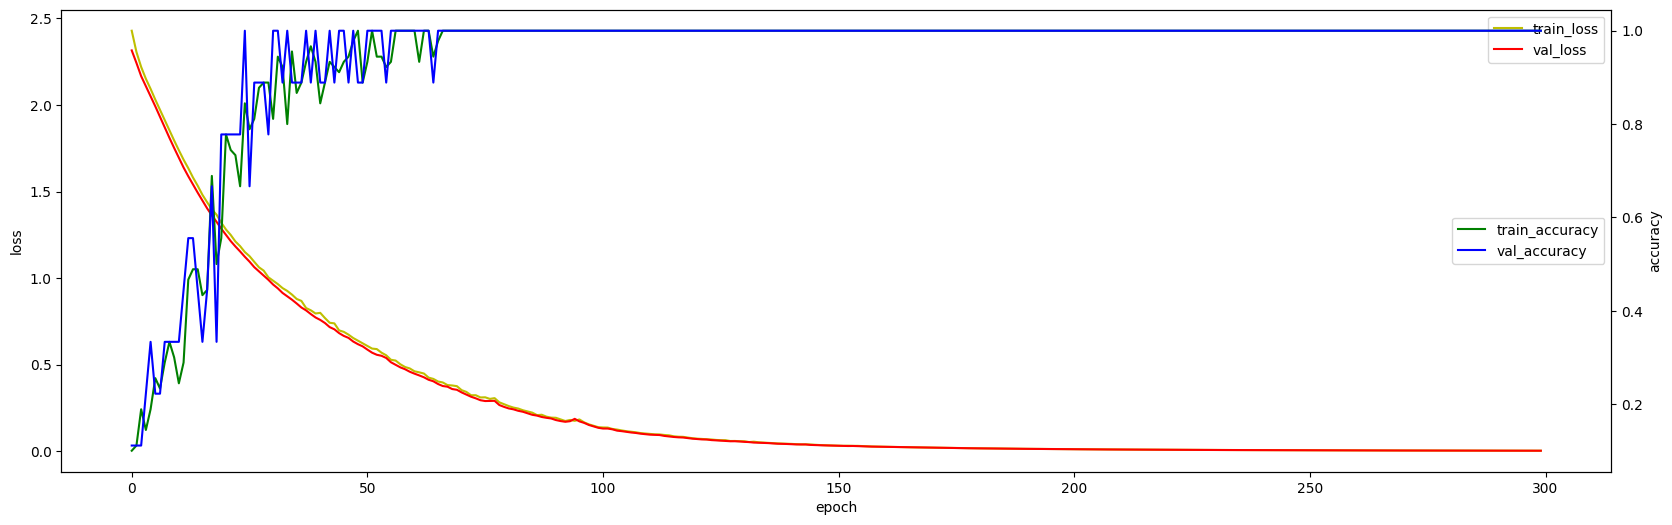

In [48]:
#학습과정 살펴보기
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(20,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax=loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='upper right')
acc_ax.legend(loc='center right')
plt.show()


In [51]:
#모델평가하기
score=model.evaluate(x_val,Y_val,batch_size=3)
print('loss : ', score[0])
print('accuracy : ', score[1])

3/3 [==============================] - 0s 5ms/step - loss: 0.0032 - accuracy: 1.0000
loss :  0.0032002024818211794
accuracy :  1.0


# 7. 모델저장

In [ ]:
model.save('model/02_deep.h5') #모델 저장 파일:h5.keras는 2.14이후버전이라 안맞음

In [ ]:
#저장된 모델사용하기
model1=load_model('model/02_deep.h5')

# 7. 모델사용하기(예측하기)

In [56]:
#y_hat : 전부
h=model.predict(np.array([5]))
h.argmax()

1/1 [==============================] - 0s 36ms/step


6

In [57]:
model.predict(np.array([2])).argmax()

1/1 [==============================] - 0s 38ms/step


3

In [59]:
# 몇 %확률로 5라고 예측했나??
h[0,h.argmax()]*100

99.72583055496216

In [61]:
h[0,[5,6,7]]*100

array([ 0.1350921, 99.72583  ,  0.1390714], dtype=float32)